In [1]:
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("ggplot")
df = pd.read_csv("biotech-crops-all-tables-2024.csv", encoding="latin1")
df.head()

,Attribute,State,Year,Value,Table
0,Insect-resistant (Bt) only (percent of all cor...,Illinois,2000,13,Genetically engineered (GE) corn varieties by ...
1,Insect-resistant (Bt) only (percent of all cor...,Illinois,2001,12,Genetically engineered (GE) corn varieties by ...
2,Insect-resistant (Bt) only (percent of all cor...,Illinois,2002,18,Genetically engineered (GE) corn varieties by ...
3,Insect-resistant (Bt) only (percent of all cor...,Illinois,2003,23,Genetically engineered (GE) corn varieties by ...
4,Insect-resistant (Bt) only (percent of all cor...,Illinois,2004,26,Genetically engineered (GE) corn varieties by ...


In [2]:
df["Value"] = (
    df["Value"]
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

In [3]:
df = df.dropna(subset=["Value"])

In [4]:
df_wide = df.pivot_table(
    index=["State", "Year"],
    columns="Attribute",
    values="Value",
    aggfunc="first"
).reset_index()

In [5]:
df_wide.columns = df_wide.columns.str.strip()

In [6]:
corn_cols = ["State", "Year"] + [
    col for col in df_wide.columns if "corn" in col.lower()
]

df_corn = df_wide[corn_cols].dropna()

In [7]:
df_corn = df_corn.rename(columns={
    "All GE varieties (percent of all corn planted)": "GE_total",
    "Herbicide-tolerant (HT) only (percent of all corn planted)": "HT",
    "Insect-resistant (Bt) only (percent of all corn planted)": "Bt",
    "Stacked gene varieties (percent of all corn planted)": "Stacked"
})

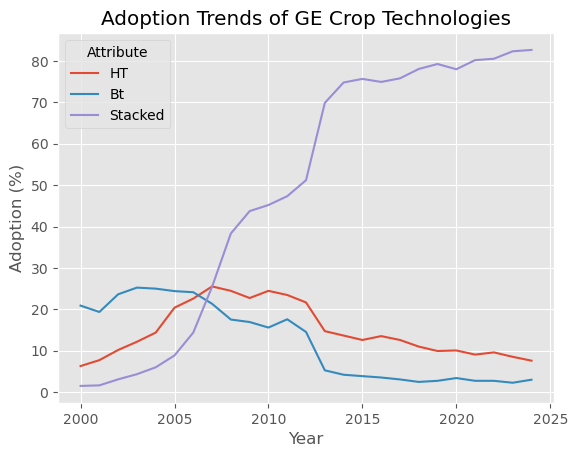

In [8]:
import matplotlib.pyplot as plt
plt.style.use("ggplot")

df_corn.groupby("Year")[["HT", "Bt", "Stacked"]].mean().plot()
plt.title("Adoption Trends of GE Crop Technologies")
plt.xlabel("Year")
plt.ylabel("Adoption (%)")
plt.show()

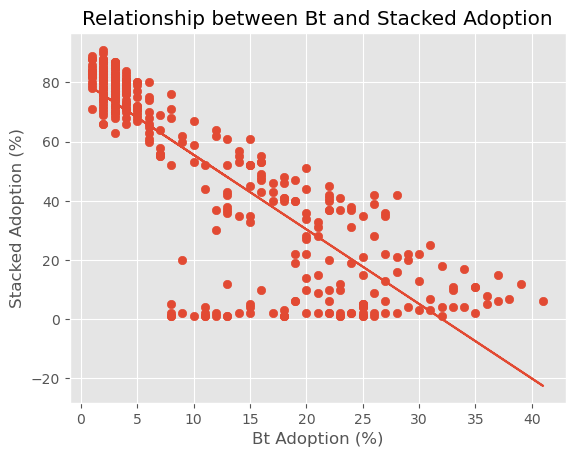

In [9]:
import numpy as np

x = df_corn["Bt"]
y = df_corn["Stacked"]

m, b = np.polyfit(x, y, 1)

plt.scatter(x, y)
plt.plot(x, m*x + b)
plt.xlabel("Bt Adoption (%)")
plt.ylabel("Stacked Adoption (%)")
plt.title("Relationship between Bt and Stacked Adoption")
plt.show()

In [10]:
from linearmodels.panel import PanelOLS

df_panel = df_corn.set_index(["State", "Year"])

model = PanelOLS.from_formula(
    "Stacked ~ HT + Bt + EntityEffects + TimeEffects",
    data=df_panel
).fit()

print(model)

                          PanelOLS Estimation Summary                           
Dep. Variable:                Stacked   R-squared:                        0.2290
Estimator:                   PanelOLS   R-squared (Between):             -0.2568
No. Observations:                 357   R-squared (Within):               0.2634
Date:                Sat, Apr 04 2026   R-squared (Overall):             -0.1249
Time:                        17:35:56   Log-likelihood                   -989.62
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      46.936
Entities:                          15   P-value                           0.0000
Avg Obs:                       23.800   Distribution:                   F(2,316)
Min Obs:                       20.000                                           
Max Obs:                       25.000   F-statistic (robust):             46.936
                            